In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [4]:
from PIL import Image
import os

directory = "E:\IIT Year 2\Sem 1\DSGP\Images"

def convert_images_to_jpg(directory):
    for folder_name in os.listdir(directory):
        folder_path = os.path.join(directory, folder_name)
        if os.path.isdir(folder_path):
            for file_name in os.listdir(folder_path):
                file_path = os.path.join(folder_path, file_name)
                try:
                    with Image.open(file_path) as img:
                        if img.format != 'JPEG':
                            new_file_path = file_path.rsplit('.', 1)[0] + '.jpg'
                            img.convert('RGB').save(new_file_path, 'JPEG')
                            os.remove(file_path)  
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

convert_images_to_jpg(directory)


<>:4: SyntaxWarning: invalid escape sequence '\I'
<>:4: SyntaxWarning: invalid escape sequence '\I'
C:\Users\dulin\AppData\Local\Temp\ipykernel_27248\2396381816.py:4: SyntaxWarning: invalid escape sequence '\I'
  directory = "E:\IIT Year 2\Sem 1\DSGP\Images"


In [5]:
data_path = "E:\IIT Year 2\Sem 1\DSGP\Images"

<>:1: SyntaxWarning: invalid escape sequence '\I'
<>:1: SyntaxWarning: invalid escape sequence '\I'
C:\Users\dulin\AppData\Local\Temp\ipykernel_27248\39687889.py:1: SyntaxWarning: invalid escape sequence '\I'
  data_path = "E:\IIT Year 2\Sem 1\DSGP\Images"


In [6]:
dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True
)


Found 3963 files belonging to 2 classes.


In [7]:
def split_dataset(dataset, train = 0.7, val = 0.2):
    dataset_size = len(dataset)
    training_size = int(dataset_size*train)
    validation_size = int(dataset_size*val)

    train_dataset = dataset.take(training_size)
    validation_dataset = dataset.skip(training_size).take(validation_size)
    test_dataset = dataset.skip(training_size+validation_size)

    return train_dataset, validation_dataset, test_dataset

In [8]:
train_dataset, validation_dataset, test_dataset = split_dataset(dataset)

In [9]:
for image_batch, label_batch in train_dataset.take(1):
    print(image_batch.shape)
    print(label_batch.shape)

(32, 128, 128, 3)
(32,)


In [10]:
from tensorflow.keras.applications import VGG19, ResNet50
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg19_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

In [11]:
train_dataset_vgg = train_dataset.map(lambda x, y: (vgg19_preprocess(x), y))
validation_dataset_vgg = validation_dataset.map(lambda x, y: (vgg19_preprocess(x), y))
test_dataset_vgg = test_dataset.map(lambda x, y: (vgg19_preprocess(x), y))

train_dataset_resnet = train_dataset.map(lambda x, y: (resnet_preprocess(x), y))
validation_dataset_resnet = validation_dataset.map(lambda x, y: (resnet_preprocess(x), y))
test_dataset_resnet = test_dataset.map(lambda x, y: (resnet_preprocess(x), y))

In [12]:
def build_and_train_model(base_model, train_data, val_data, model_name):
    base_model.trainable = False  
    model = tf.keras.models.Sequential([
        base_model,
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid') 
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(),
                  loss=tf.keras.losses.BinaryCrossentropy(),
                  metrics=['accuracy'])

    history = model.fit(train_data, epochs=10, validation_data=val_data)

    model.save(f"{model_name}.h5")  
    return model, history

In [13]:
pretrained_vgg19 = tf.keras.applications.VGG19(
    include_top=False,
    input_shape=(128, 128, 3),
    weights='imagenet',
    pooling='max'
)
vgg19_model, vgg19_history = build_and_train_model(pretrained_vgg19, train_dataset_vgg, validation_dataset_vgg, "vgg19_balcony_model")

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.6443 - loss: 13.3837 - val_accuracy: 0.8568 - val_loss: 0.8513
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.8527 - loss: 1.0193 - val_accuracy: 0.8997 - val_loss: 0.3531
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.8731 - loss: 0.4998 - val_accuracy: 0.9036 - val_loss: 0.2604
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.8996 - loss: 0.2660 - val_accuracy: 0.9271 - val_loss: 0.1839
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.9265 - loss: 0.2048 - val_accuracy: 0.9284 - val_loss: 0.1662
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.9321 - loss: 0.1737 - val_accuracy: 0.9414 - val_loss: 0.1405
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.9389 - loss: 0.1521 - val_accuracy: 0.9310 - val_loss: 0.1494
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.9415 - loss: 0.1457 - val_accuracy: 0.9518 - val_

In [14]:
pretrained_resnet50 = tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=(128, 128, 3),
    weights='imagenet',
    pooling='max'
)


In [15]:
resnet50_model, resnet50_history = build_and_train_model(pretrained_resnet50, train_dataset_resnet, validation_dataset_resnet, "resnet50_balcony_model")

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 50s 519ms/step - accuracy: 0.7103 - loss: 2.6468 - val_accuracy: 0.9115 - val_loss: 0.2239
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 43s 498ms/step - accuracy: 0.8917 - loss: 0.2733 - val_accuracy: 0.9349 - val_loss: 0.1892
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 43s 497ms/step - accuracy: 0.9239 - loss: 0.1975 - val_accuracy: 0.9245 - val_loss: 0.1888
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 43s 493ms/step - accuracy: 0.9381 - loss: 0.1554 - val_accuracy: 0.9323 - val_loss: 0.1465
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 43s 495ms/step - accuracy: 0.9302 - loss: 0.1429 - val_accuracy: 0.9479 - val_loss: 0.1502
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 43s 494ms/step - accuracy: 0.9509 - loss: 0.1188 - val_accuracy: 0.9492 - val_loss: 0.1257
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 43s 495ms/step - accuracy: 0.9663 - loss: 0.0849 - val_accuracy: 0.9557 - val_loss: 0.1074
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 43s 496ms/step - accuracy: 0.9668 - loss: 0.0842 - val_accu

In [16]:
def evaluate_model(model, test_data, model_name):
    test_loss, test_accuracy = model.evaluate(test_data, verbose=1)
    print(f"\n{model_name} - Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


In [17]:
evaluate_model(vgg19_model, test_dataset_vgg, "VGG19")

14/14 ━━━━━━━━━━━━━━━━━━━━ 16s 830ms/step - accuracy: 0.9496 - loss: 0.1307

VGG19 - Test Loss: 0.1222, Test Accuracy: 0.9549


In [18]:
evaluate_model(resnet50_model, test_dataset_resnet, "ResNet50")

14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 354ms/step - accuracy: 0.9559 - loss: 0.0970

ResNet50 - Test Loss: 0.0885, Test Accuracy: 0.9616


In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import tensorflow as tf

In [27]:
def get_predictions_and_labels(model, test_data):
    predictions = []
    true_labels = []
    
    for images, labels in test_data:
        preds = model.predict(images, verbose=0)
        preds_binary = (preds > 0.5).astype(int).flatten()
        predictions.extend(preds_binary)
        true_labels.extend(labels.numpy().flatten())
    
    return np.array(predictions), np.array(true_labels)

def print_metrics(model, test_data, model_name):
    y_pred, y_true = get_predictions_and_labels(model, test_data)
    
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_true, y_pred, target_names=["Balcony", "Indoor"]))
    
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nConfusion Matrix for {model_name}:")
    print(cm)
    
    tn, fp, fn, tp = cm.ravel()
    print(f"True Negatives (Balcony correct): {tn}")
    print(f"False Positives (Balcony predicted as Indoor): {fp}")
    print(f"False Negatives (Indoor predicted as Balcony): {fn}")
    print(f"True Positives (Indoor correct): {tp}")
    
    return cm

print_metrics(vgg19_model, test_dataset_vgg, "VGG19")

metrics = print_metrics(resnet50_model, test_dataset_resnet, "ResNet50")


Classification Report for VGG19:
              precision    recall  f1-score   support

     Balcony       0.97      0.90      0.93       220
      Indoor       0.91      0.97      0.94       223

    accuracy                           0.94       443
   macro avg       0.94      0.94      0.94       443
weighted avg       0.94      0.94      0.94       443


Confusion Matrix for VGG19:
[[199  21]
 [  7 216]]
True Negatives (Balcony correct): 199
False Positives (Balcony predicted as Indoor): 21
False Negatives (Indoor predicted as Balcony): 7
True Positives (Indoor correct): 216

Classification Report for ResNet50:
              precision    recall  f1-score   support

     Balcony       0.98      0.94      0.96       204
      Indoor       0.95      0.98      0.97       239

    accuracy                           0.96       443
   macro avg       0.96      0.96      0.96       443
weighted avg       0.96      0.96      0.96       443


Confusion Matrix for ResNet50:
[[191  13]
 [  4 

AttributeError: 'NoneType' object has no attribute 'flatten'

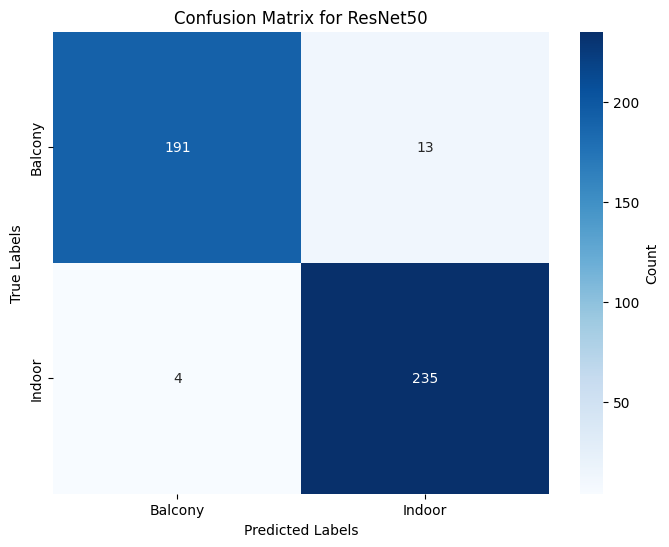

In [29]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(metrics, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'}, 
            xticklabels=["Balcony", "Indoor"], yticklabels=["Balcony", "Indoor"])
plt.title('Confusion Matrix for ResNet50')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.colorbar(label='Count', ticks=range(0, max(resnet50_cm.flatten()) + 100, 100))  # Dynamic range
plt.show()